# 11. Real-World Problem Solving Using Supervised and Unsupervised Learning

## 📚 Learning Objectives

By completing this notebook, you will:
- Solve real-world problems
- Combine supervised and unsupervised learning
- Apply ML techniques
- Evaluate solutions
- Present results

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 4, lessons 02-10 (the full supervised and unsupervised toolkit) and Unit 1, lesson 07, which framed the same kind of problem before you could model it.

**Used later in:** Course 12 (AIAT 126) — Units 1 and 3, where this is the shape of the graduation project itself.

---

This notebook covers practical activities from **Course 05, Unit 4**:
- Real-world problem solving using a mix of supervised and unsupervised learning algorithms

---

## Introduction

**Real-world problem solving** often requires combining supervised and unsupervised learning techniques to address complex data science challenges effectively.


## The Story

**BEFORE**: You know individual ML techniques but haven't applied them to solve complete real-world problems.

**AFTER**: You'll solve a complete real-world problem: from data to model to evaluation - end-to-end ML project!

**Why this matters**: Real-World Problem Solving Using Supervised and Unsupervised Learning is essential for building complete, professional data science solutions!

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Real data:** `titanic.csv` — the 891-passenger manifest of the RMS Titanic,
  with 177 genuinely missing ages and fares spanning £0 to £512.33.
- sklearn (KMeans, LogisticRegression, StandardScaler), pandas, matplotlib

**Outputs:** What you'll see when you run the cells

- Passenger segments discovered without labels, then a survival model built with them
- Segment-by-segment survival rates and ranked model coefficients — all computed here

---


In [1]:
# WHAT: Import tools and lay out the project plan - segment the passengers, then predict survival.
# WHY: Real problems combine techniques; this mini-project chains an unsupervised and a supervised step.

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

print("✅ Libraries imported!")
print("\nReal-World Problem Solving: End-to-End Mini Project")
print("=" * 60)
print("""
The question: the RMS Titanic sank on 15 April 1912 with 891 passengers on
the recorded manifest. Two things a historian (or a modern safety analyst)
would want to know:
  1. WHO was on board? - SEGMENT the passengers (unsupervised, no labels needed)
  2. WHO survived, and why? - PREDICT survival (supervised, labelled outcome)

Plan: data -> explore -> K-Means segments -> survival model -> insights
Every number below comes from the real manifest.
""")

✅ Libraries imported!

Real-World Problem Solving: End-to-End Mini Project

The question: the RMS Titanic sank on 15 April 1912 with 891 passengers on
the recorded manifest. Two things a historian (or a modern safety analyst)
would want to know:
  1. WHO was on board? - SEGMENT the passengers (unsupervised, no labels needed)
  2. WHO survived, and why? - PREDICT survival (supervised, labelled outcome)

Plan: data -> explore -> K-Means segments -> survival model -> insights
Every number below comes from the real manifest.



## Step 1: The Data

The real RMS Titanic passenger manifest (891 rows, a public historical record).
`Survived` is our supervised label; everything else describes who the passenger was.
177 ages are genuinely missing — we fill them with the median and say so.


In [2]:
# WHAT: Load the real Titanic manifest and derive the three behaviour features we cluster on.
# WHY: This is a historical record, not a simulation - the signal the model finds is a fact
#      about 1912, and we can check the model against what historians already know.

print("Step 1: Load and explore the data")
print("-" * 60)

DATA_DIR = '../../../Course 04/datasets/raw/'
passengers = pd.read_csv(DATA_DIR + 'titanic.csv')

n = len(passengers)
n_missing_age = passengers['Age'].isna().sum()
passengers['Age'] = passengers['Age'].fillna(passengers['Age'].median())
passengers['family_size'] = passengers['SibSp'] + passengers['Parch'] + 1
passengers['is_female'] = (passengers['Sex'] == 'female').astype(int)

print(passengers[['Name', 'Pclass', 'Sex', 'Age', 'Fare',
                  'family_size', 'Survived']].head().to_string())
print(f"\n{n} passengers on the manifest, overall survival rate: "
      f"{passengers['Survived'].mean():.1%}")
print(f"Missing ages filled with the median: {n_missing_age} "
      f"({n_missing_age / n:.1%} of the manifest)")
print("\nSummary statistics:")
print(passengers[['Age', 'Fare', 'family_size', 'Pclass', 'Survived']]
      .describe().round(2).to_string())

Step 1: Load and explore the data
------------------------------------------------------------
                                                  Name  Pclass     Sex   Age     Fare  family_size  Survived
0                              Braund, Mr. Owen Harris       3    male  22.0   7.2500            2         0
1  Cumings, Mrs. John Bradley (Florence Briggs Thayer)       1  female  38.0  71.2833            2         1
2                               Heikkinen, Miss. Laina       3  female  26.0   7.9250            1         1
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)       1  female  35.0  53.1000            2         1
4                             Allen, Mr. William Henry       3    male  35.0   8.0500            1         0

891 passengers on the manifest, overall survival rate: 38.4%
Missing ages filled with the median: 177 (19.9% of the manifest)

Summary statistics:
          Age    Fare  family_size  Pclass  Survived
count  891.00  891.00       891.00  891.00    891.

## Step 2: Unsupervised — Passenger Segments with K-Means

No labels here: we cluster on who the passengers *were* (age, fare paid, family
size) to find natural groups. The survival label is deliberately withheld from
the clustering step, so any survival difference between segments is a discovery,
not something we built in.


Step 2: K-Means passenger segmentation
------------------------------------------------------------
Segment profiles (means):
           Age    Fare  family_size  Pclass  is_female  Survived  size
segment                                                               
0        34.93  207.09         2.54    1.00       0.66      0.73    41
1        31.62   21.93         1.37    2.33       0.31      0.35   728
2        13.99   34.75         4.87    2.62       0.51      0.45   122


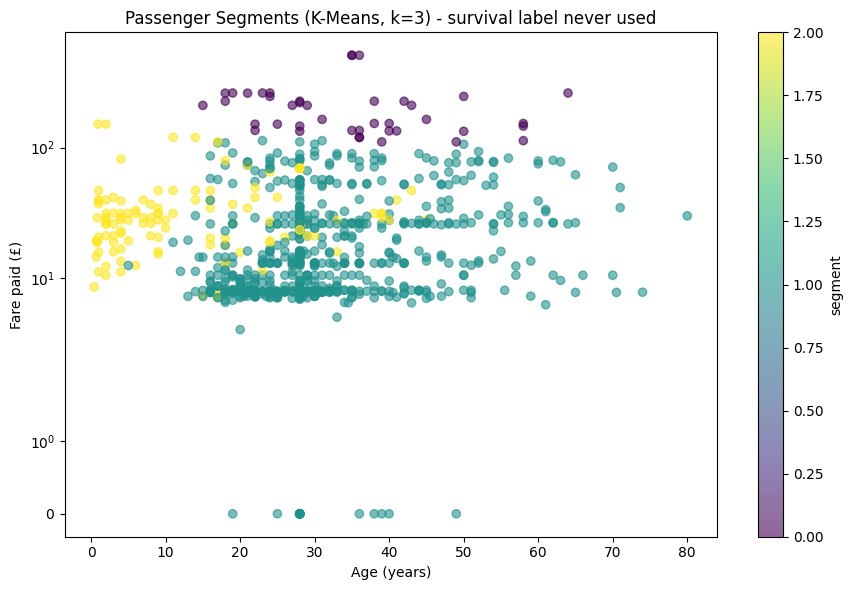

✓ Segments plotted - each color is a discovered passenger group
  (fare axis is log-scaled: the median fare was £14 and the maximum £512)


In [3]:
# WHAT: Standardize three descriptive features and segment passengers with K-Means (k=3).
# WHY: Scaling first is essential - otherwise Fare (0-512) would drown out family_size (1-11).

print("Step 2: K-Means passenger segmentation")
print("-" * 60)

seg_features = ['Age', 'Fare', 'family_size']
scaler_seg = StandardScaler()
X_seg = scaler_seg.fit_transform(passengers[seg_features])

# NOTE: 'Survived' is NOT in seg_features. The clustering never sees the outcome.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
passengers['segment'] = kmeans.fit_predict(X_seg)

profile = passengers.groupby('segment')[seg_features + ['Pclass', 'is_female', 'Survived']].mean().round(2)
profile['size'] = passengers['segment'].value_counts().sort_index()
print("Segment profiles (means):")
print(profile.to_string())

plt.figure(figsize=(9, 6))
sc = plt.scatter(passengers['Age'], passengers['Fare'],
                 c=passengers['segment'], cmap='viridis', alpha=0.6)
plt.colorbar(sc, label='segment')
plt.title('Passenger Segments (K-Means, k=3) - survival label never used')
plt.xlabel('Age (years)')
plt.ylabel('Fare paid (£)')
plt.yscale('symlog')
plt.tight_layout()
plt.show()
print("✓ Segments plotted - each color is a discovered passenger group")
print("  (fare axis is log-scaled: the median fare was £14 and the maximum £512)")

## Step 3: Supervised — Predict Survival

Now we use the labeled outcome (`Survived`) to train a classifier on the full
feature set, and read its standardized coefficients to see which characteristics
mattered most.


In [4]:
# WHAT: Train a survival classifier and rank its standardized coefficients.
# WHY: On standardized features, coefficient size is comparable - it reveals which
#      characteristics mattered most, and in which direction.

print("Step 3: Survival prediction with logistic regression")
print("-" * 60)

features = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'is_female', 'family_size']
X = passengers[features]
y = passengers['Survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

survival_model = LogisticRegression(max_iter=1000)
survival_model.fit(X_train_s, y_train)
y_pred = survival_model.predict(X_test_s)
acc = accuracy_score(y_test, y_pred)
baseline = max(y_test.mean(), 1 - y_test.mean())

print(f"Test accuracy: {acc:.2%}   (majority-class baseline: {baseline:.2%})")
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3,
                            target_names=['died', 'survived']))

print("Model coefficients (standardized features -> comparable):")
coef_order = sorted(zip(features, survival_model.coef_[0]),
                    key=lambda t: abs(t[1]), reverse=True)
for name, c in coef_order:
    direction = "raises" if c > 0 else "lowers"
    print(f"  {name:12s} {c:+.3f}  ({direction} survival odds)")

Step 3: Survival prediction with logistic regression
------------------------------------------------------------
Test accuracy: 78.03%   (majority-class baseline: 61.43%)

Classification report:
              precision    recall  f1-score   support

        died      0.824     0.818     0.821       137
    survived      0.713     0.721     0.717        86

    accuracy                          0.780       223
   macro avg      0.768     0.769     0.769       223
weighted avg      0.781     0.780     0.781       223

Model coefficients (standardized features -> comparable):
  is_female    +1.290  (raises survival odds)
  Pclass       -0.899  (lowers survival odds)
  Age          -0.523  (lowers survival odds)
  SibSp        -0.196  (lowers survival odds)
  Fare         +0.173  (raises survival odds)
  family_size  -0.124  (lowers survival odds)
  Parch        +0.008  (raises survival odds)


In [5]:
# WHAT: Combine segments and model into computed insights and a summary.
# WHY: The answer is the intersection: WHICH groups survived, and WHY.

print("=" * 60)
print("Step 4: Insights & Summary")
print("=" * 60)

seg_survival = passengers.groupby('segment')['Survived'].mean()
best = seg_survival.idxmax()
worst = seg_survival.idxmin()
top_driver = coef_order[0][0]
print(f"""
End-to-end project - what the real 1912 manifest told us (all computed above):
  - Survival rate by segment: {', '.join(f'segment {s}: {r:.1%}' for s, r in seg_survival.items())}
  - Highest-surviving segment: {best} ({seg_survival[best]:.1%}) - mean fare
    £{profile.loc[best, 'Fare']:.0f}, mean age {profile.loc[best, 'Age']:.0f}, mean class {profile.loc[best, 'Pclass']:.1f}
  - Lowest-surviving segment: {worst} ({seg_survival[worst]:.1%}) - mean fare
    £{profile.loc[worst, 'Fare']:.0f}, mean age {profile.loc[worst, 'Age']:.0f}, mean class {profile.loc[worst, 'Pclass']:.1f}
  - Strongest survival driver in the model: {top_driver} ({coef_order[0][1]:+.3f})
  - Survival model test accuracy: {acc:.2%} (baseline {baseline:.2%})

The full workflow we just executed:
  1. Data collection & exploration (pandas) on a real historical record
  2. Unsupervised segmentation (K-Means) - the outcome label was withheld
  3. Supervised prediction (logistic regression) - labelled outcome used
  4. Insights that combine both: which SEGMENTS survived, and which
     characteristics the model says explain it

⚠️  Read the result carefully. The model is describing a 1912 evacuation in which
   "women and children first" was enforced and lifeboat access depended on deck
   position, which depended on ticket class. The coefficients report that
   historical reality; they are not a rule for any decision today.

Next: Example 12 asks what happens to this workflow when data
gets much bigger - CPU vs GPU for ML.
""")
print("✅ End-to-end real-world problem solving - complete!")

Step 4: Insights & Summary

End-to-end project - what the real 1912 manifest told us (all computed above):
  - Survival rate by segment: segment 0: 73.2%, segment 1: 35.3%, segment 2: 45.1%
  - Highest-surviving segment: 0 (73.2%) - mean fare
    £207, mean age 35, mean class 1.0
  - Lowest-surviving segment: 1 (35.3%) - mean fare
    £22, mean age 32, mean class 2.3
  - Strongest survival driver in the model: is_female (+1.290)
  - Survival model test accuracy: 78.03% (baseline 61.43%)

The full workflow we just executed:
  1. Data collection & exploration (pandas) on a real historical record
  2. Unsupervised segmentation (K-Means) - the outcome label was withheld
  3. Supervised prediction (logistic regression) - labelled outcome used
  4. Insights that combine both: which SEGMENTS survived, and which
     characteristics the model says explain it

⚠️  Read the result carefully. The model is describing a 1912 evacuation in which
   "women and children first" was enforced and lifeboa

## 📚 References

1. Sculley, D., Holt, G., Golovin, D., et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS 28. <https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html>
2. Domingos, P. (2012). *A Few Useful Things to Know About Machine Learning*. Communications of the ACM, 55(10), 78-87. <https://doi.org/10.1145/2347736.2347755>
3. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning*, 2nd ed. Springer. <https://www.statlearning.com>